# Sin Preprocesamiento


En el presente notebook se generan y se evalúan los siguientes modelos.

* Regresión lineal (regularizada según elastic net)
* Árbol de regresión
* KNN para regresión
* Regresión no paramétrica

Al no utilizar ningún tipo de preprocesamiento, nos permite tener valores de referencia sobre los score de los distintos modelos. De este modo, podremos comparar los presentes resultados con los obtenidos al modificar previamente el set de datos, y concluir si el preprocesamiento fue bueno o no. 

In [1]:
library(pracma)
library(glmnet)
library(ggplot2)
library(stats)
library(partykit)
source("Utils.R")

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:pracma’:

    expm, lu, tril, triu


Loaded glmnet 4.1-2

Loading required package: grid

Loading required package: libcoin

Loading required package: mvtnorm



In [40]:
library(reticulate)
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

StScaler <- import("sklearn.preprocessing", convert = FALSE)$StandardScaler
MMScaler <- import("sklearn.preprocessing", convert = FALSE)$MinMaxScaler

### Division de los datos

In [4]:
setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()

df <- vasijas_X
df$Y <- vasijas_Y


hold_out_ind <- obtener_holdout_ind(vasijas_X)

HOLDOUT_X <- vasijas_X[hold_out_ind, ]
HOLDOUT_Y <- vasijas_Y[hold_out_ind]
HOLDOUT_DF <- df[hold_out_ind, ]

TRAIN_Y <- vasijas_Y[-hold_out_ind]
TRAIN_X <- vasijas_X[-hold_out_ind, ]
TRAIN_DF <- df[-hold_out_ind, ]

# Modelo 1: regresión lineal regularizada

### Sólo iterando lambda y sin escalar

In [3]:
model <- glmnet(as.matrix(TRAIN_X), TRAIN_Y)

In [4]:
Y_pred = predict(model, as.matrix(TRAIN_X))
error_min <- sum((TRAIN_Y - Y_pred[, 1])^2) / nrow(TRAIN_X)
best_model <- 1
for (i in 2:ncol(Y_pred)) {
    curr_error <- sum((TRAIN_Y - Y_pred[, i])^2) / nrow(TRAIN_X)
    if (curr_error < error_min) {
        error_min <- curr_error 
        best_model <- i
    }
}
print(paste("El error cuadratico medio de train es: ", error_min, " usando el modelo numero: ", best_model))

[1] "El error cuadratico medio de train es:  0.694377895643682  usando el modelo numero:  100"


In [5]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
for(i in indices){

    X_train_scaled = X[-i,]
    Y_train = TRAIN_Y[-i]

    X_test_scaled = X[i,]
    Y_test = TRAIN_Y[i]

    model <- glmnet(as.matrix(X_train_scaled), Y_train, lambda=0.0372, alpha=1)
    Y_pred = predict(model, as.matrix(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  1.25984304435739"


Es claro que hay un overfitting bastante grande

### Busqueda de los parametros de la prediccion

In [32]:
setSeed()
n = nrow(TRAIN_X)
k = 5
resultados <- data.frame(
  Alpha   =double(),
  Lambda  =double(),
  Scaler  =double(),
  Error   =double()
)

indices = obtener_indices_kfold(n, k)
X <- TRAIN_X

alphas <- seq(0, 1, 0.05)
lambdas <- logspace(-10, 3, 50)
escaladores <- c(StScaler(), MMScaler())
for (alpha in alphas) {
    for (lambda in lambdas) {
        for(s in 1:length(escaladores)){
            escalador = escaladores[[s]]
            err = 0
            for (i in indices) {
                X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
                Y_train = TRAIN_Y[-i]

                X_test_scaled = as.matrix(escalador$transform(X[i, ]))
                Y_test = TRAIN_Y[i]

                model <- glmnet(X_train_scaled, Y_train, lambda=lambda, alpha=alpha)
                Y_pred = predict(model, X_test_scaled)
                err = err + sum((Y_test - Y_pred)^2)
            }
            resultados = rbind(resultados, list(alpha, lambda, s, err/n))
        }
    }
    message(progreso(alpha, alphas))
}

colnames(resultados)  <- c("alpha", "lambda", "Escalador", "Error")

El progreso es del 4.8 %

El progreso es del 9.5 %

El progreso es del 14.3 %

El progreso es del 19 %

El progreso es del 23.8 %

El progreso es del 28.6 %

El progreso es del 33.3 %

El progreso es del 38.1 %

El progreso es del 42.9 %

El progreso es del 47.6 %

El progreso es del 52.4 %

El progreso es del 57.1 %

El progreso es del 61.9 %

El progreso es del 66.7 %

El progreso es del 71.4 %

El progreso es del 76.2 %

El progreso es del 81 %

El progreso es del 85.7 %

El progreso es del 90.5 %

El progreso es del 95.2 %

El progreso es del 100 %



Los mejores parámetros obtenidos fueron entonces:

In [33]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,alpha,lambda,Escalador,Error
,<dbl>,<dbl>,<int>,<dbl>
368,0.15,0.05689866,2,0.9506797


### Calculo del error por LOOCV

In [34]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
escalador = escaladores[[mejores_parametros$Escalador]]
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- glmnet(X_train_scaled, Y_train, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)
    Y_pred = predict(model, X_test_scaled)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.864977154163412"


Vemos que el error de LOOCV dio menor

In [45]:
X_scaled <- scale(TRAIN_X)
X_holdout_scaled <- scale(HOLDOUT_X, center=attr(X_scaled, "scaled:center"),
                          scale=attr(X_scaled, "scaled:scale"))
modelo1 <- glmnet(X_scaled, TRAIN_Y, alpha=mejores_parametros$alpha, lambda=mejores_parametros$lambda)

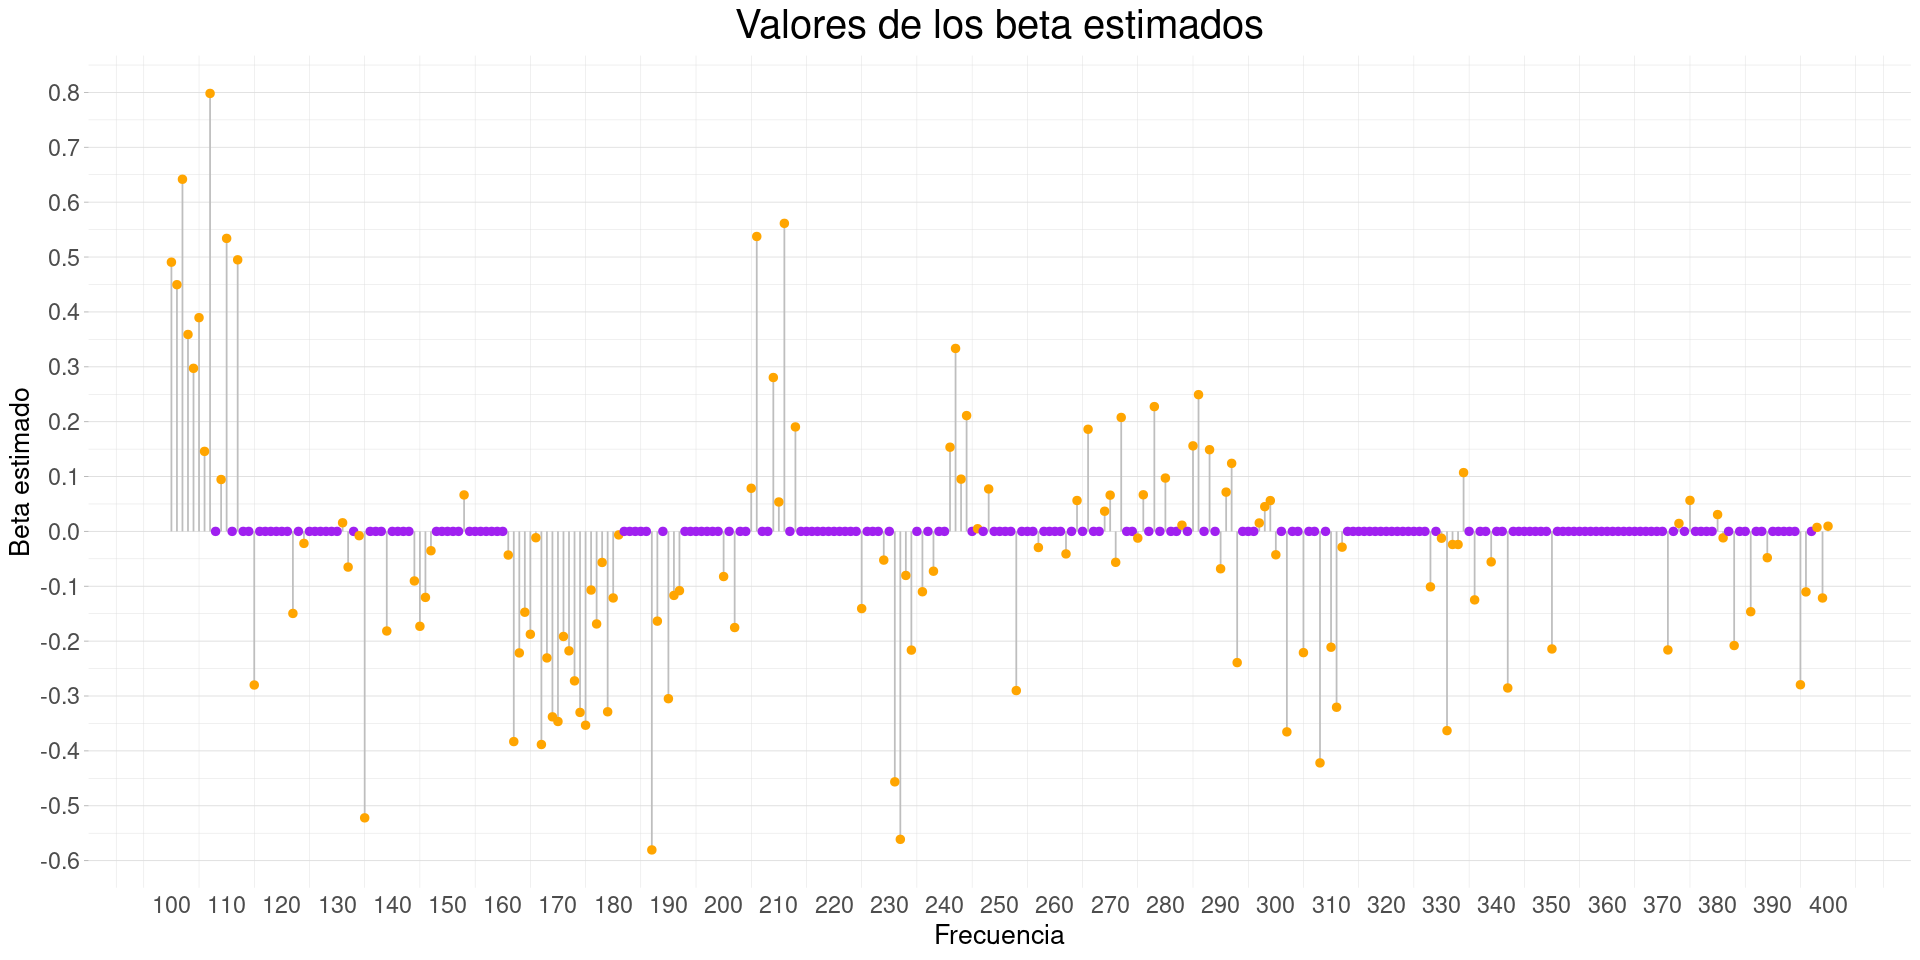

In [89]:
x_plot = as.integer(sub('.', '', colnames(TRAIN_X))) + 99

data_plot <- data.frame(
  x=x_plot,
  y=modelo1$beta[,1]
)


# Plot

options(repr.plot.width=16, repr.plot.height=8)

colores = sapply(modelo1$beta[,1], function(x) (ifelse(x!=0, "orange",  "purple")))
ggplot(data_plot, aes(x=x, y=y)) +
  ggtitle("Valores de los beta estimados") +
  geom_segment( aes(x=x, xend=x, y=0, yend=y), color="grey") +
  geom_point(color=colores, size=2) +
  theme_light() +
  theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank()) +
  scale_x_continuous(breaks = seq(100, 400, by=10)) +
  scale_y_continuous(breaks = seq(-1, 1, by=0.1)) +
  xlab("Frecuencia") + ylab("Beta estimado")

Cálculo de R^2adj


err = ||Y-Ŷ||^2/n

In [95]:
p = sum(modelo1$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
hatY

[1] 0.7683796

### Analisis del grafico

En el presente grafico se puede observar la importancia que le da el modelo a las distintas variables $X_i$. Dado que el valor de $\alpha = 0.15 $ es cercano a cero, es esperable que muchas variables no sean tenidas en cuenta por el modelo (hay penalizacion por la distancia $L1$). Ademas, aunque no es muy notorio, pareciera que las variables a las que se les da mayor importancia son a las de frecuencia baja, mientras que a las de frecuencia alta, se les da poco protagonismo en el modelo

# Modelo 2: árbol de regresión

### Sin tuneo de parametros

In [ ]:
model <- ctree(Y ~ ., data = TRAIN_DF)

In [ ]:
plot(model)

In [ ]:
Y_pred = predict(model, TRAIN_X)
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

### Busqueda de los parametros de la prediccion

In [2]:
library(rpart)
library(rpart.plot)

In [33]:
setSeed()

n = nrow(TRAIN_X)
k = 40

resultados <- data.frame(
  Minsplit =double(),
  Maxdepth =double(),
  CP    =double(),
  Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- TRAIN_X

minsplits <- c(2, 5, 10, 15, 20, 25)

for (minsplit in minsplits) {
    for (maxdepth in c(4, 5, 6, 7, 8)) {
        for (cp in c(0.0005, 0.001, 0.005, 0.01, 0.015, 0.025)) {
            parametros = rpart.control(minsplit=minsplit, maxdepth=maxdepth, cp=cp)
            err = 0
            for(i in indices) {
                DF_train = X[-i,]
                DF_train$Y = TRAIN_Y[-i]

                DF_test = X[i,]
                DF_test$Y = TRAIN_Y[i]
                
                model <- rpart(Y ~ ., data = DF_train, control=parametros, xval=1)
                Y_pred = predict(model, DF_test)
                err = err + sum((DF_test$Y - Y_pred)^2)
            }
            resultados = rbind(resultados, list(minsplit, maxdepth, cp, err/n))
        }
    }
    message(progreso(minsplit, minsplits))
}

colnames(resultados)  <- c("Minsplit", "Maxdepth", "CP", "Error")

El progreso es del 16.7 %

El progreso es del 33.3 %

El progreso es del 50 %

El progreso es del 66.7 %

El progreso es del 83.3 %

El progreso es del 100 %



In [34]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,Minsplit,Maxdepth,CP,Error
,<dbl>,<dbl>,<dbl>,<dbl>
4,2,4,0.01,1.434475


### Calculo del error

In [35]:
parametros <- rpart.control(minsplit=mejores_parametros$Minsplit, maxdepth=mejores_parametros$Maxdepth, cp=mejores_parametros$CP)

modelo2 <- rpart(Y ~ ., data = TRAIN_DF, control=parametros)

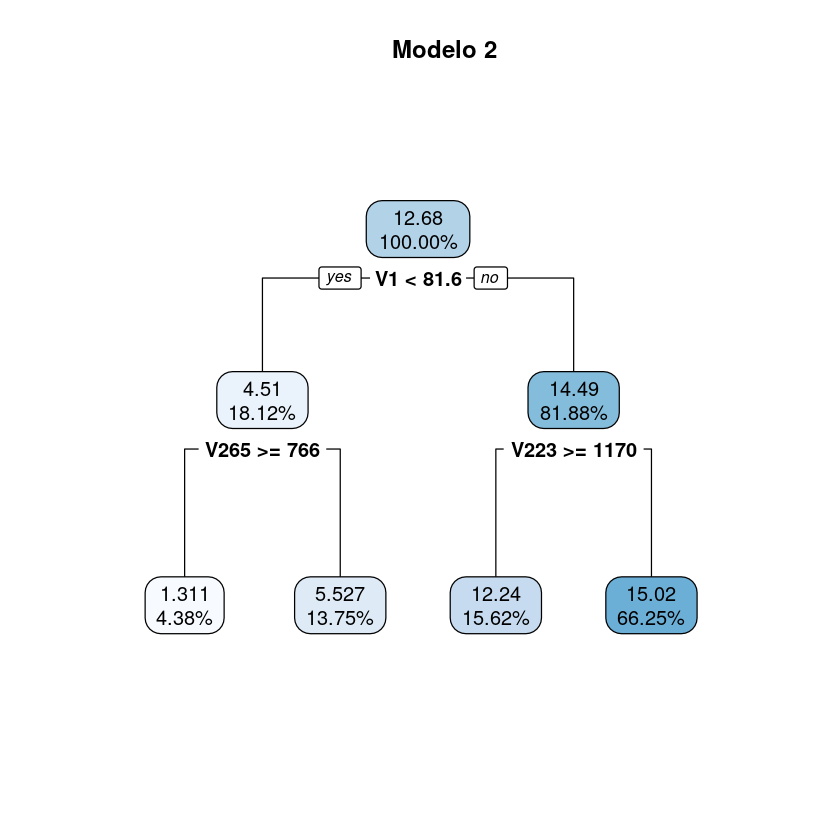

In [36]:
rpart.plot(modelo2, digits=4)
title("Modelo 2")

In [37]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
for(i in indices){
    train_df <- X[-i,]
    train_df$Y <- TRAIN_Y[-i]
    X_test <- X[i,]
    Y_test = TRAIN_Y[i]

    model <- rpart(Y ~ ., data = train_df, control=parametros)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  1.66823670146857"


In [38]:
p = 3
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
hatY

[1] 0.9032593

In [105]:
library(rpart)

# Modelo 3: KNN para regresión

In [41]:
knnr <- import("sklearn.neighbors", convert = FALSE)$KNeighborsRegressor

### Sin tuneo de parametros

In [42]:
model <- knnr()$fit(TRAIN_X, TRAIN_Y)

In [43]:
Y_pred = as.double(model$predict(TRAIN_X))
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

[1] "El error cuadratico medio de train es:  0.81237114575"


### Busqueda de los parametros de la prediccion

In [ ]:
for (alpha in alphas) {
    for (lambda in lambdas) {


In [50]:
setSeed()

n = nrow(TRAIN_X)
k = 10

resultados <- data.frame(
    K        =integer(),
    Weights  =integer(),
    p        =integer(),
    S        =integer(),
    Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- TRAIN_X
escaladores <- c(StScaler(), MMScaler())
for(K in 1:10){
    for(w in c(1, 2)){
        wei = ifelse(w==1, "uniform", "distance")
        for(p in c(1, 2)){
            for(s in 1:length(escaladores)){
                escalador = escaladores[[s]]
                err = 0
                for(i in indices){
                    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
                    Y_train = TRAIN_Y[-i]

                    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
                    Y_test = TRAIN_Y[i]
                    
                    model <- knnr(n_neighbors=K, p=p, weights=wei)$fit(X_train_scaled, Y_train)
                    Y_pred = as.double(model$predict(X_test_scaled))
                    err = err + sum((Y_test - Y_pred)^2)
                }
                resultados = rbind(resultados, list(K, w, p, s, err/n))
            }
        }
    }
    message(progreso(K, 1:10))
}
colnames(resultados)  <- c("K", "Weights", "Distance", "Escalador", "Error")

El progreso es del 10 %

El progreso es del 20 %

El progreso es del 30 %

El progreso es del 40 %

El progreso es del 50 %

El progreso es del 60 %

El progreso es del 70 %

El progreso es del 80 %

El progreso es del 90 %

El progreso es del 100 %



In [51]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,K,Weights,Distance,Escalador,Error
,<int>,<dbl>,<dbl>,<int>,<dbl>
16,2,2,2,2,0.8261919


### Calculo del error

In [53]:
escalador = escaladores[[mejores_parametros$Escalador]]
X_scaled <- escalador$fit_transform(TRAIN_X)

wei <- ifelse(mejores_parametros$Weights==1, "uniform", "distance")
modelo3 <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$Distance, weights=wei)$fit(X_scaled, TRAIN_Y)

Cálculo del error mediante LOOCV

In [54]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
escalador = escaladores[[mejores_parametros$Escalador]]
wei <- ifelse(mejores_parametros$Weights==1, "uniform", "distance")
err = 0
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$Distance, weights=wei)$fit(X_train_scaled, Y_train)
    Y_pred = as.double(model$predict(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.824904241242088"


In [70]:
p = 152
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
hatY

[1] 0.06121805

# Modelo 4: regresión no paramétrica

$$\hat{m}_{h}(x) = \frac{\sum^{n}_{i=1} K(\frac{x-x_i}{h}) y_i}{\sum^{n}_{i=1}K(\frac{x-x_i}{h})} = \sum^{n}_{i=1} w_i(x) y_i$$

In [292]:
D <- function(x, y) (sum((abs(x-y))))
calc <- function(X, Y, h, K, x0){
    wis <- apply(X, 1, function(xi) (K(D(xi, x0)/h)))
    return(sum(wis*Y)/sum(wis))
}
npr <- function(x, X, Y, h, K){
    return(apply(x, 1, function(x0) (calc(X, Y, h, K, x0))))
}

In [310]:
setSeed()

n = nrow(TRAIN_X)
k = 10

indices = obtener_indices_kfold(n, k)
X <- TRAIN_X

resultados <- data.frame(
    h       =double(),
    K       =integer(),
    Error   =double()
)
escalador = MMScaler()

hs = seq(0.1, 15, l=30)
Ks = list((function(x) (0.5 * (abs(x)<1))),
          (function(x) (dnorm(x))),
          (function(x) (0.75*(1-x^2)*(abs(x)<1))),
          (function(x) ((15/16)*((1-x^2)^2)*(abs(x)<1)))
       )

for(h in hs){
    for(Knumber in 1:length(Ks)){
        K = Ks[[Knumber]]
        err = 0
        for(i in indices){
            X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
            Y_train = TRAIN_Y[-i]

            X_test_scaled = as.matrix(escalador$transform(X[i, ]))
            Y_test = TRAIN_Y[i]
            
            Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, h, K)
            err = err + sum((Y_test - Y_pred)^2)
        }
        resultados = rbind(resultados, list(h, Knumber, err/n))
    }
    message(progreso(h, hs))
}
colnames(resultados)  <- c("h", "K", "Error")

El progreso es del 3.3 %

El progreso es del 6.7 %

El progreso es del 10 %

El progreso es del 13.3 %

El progreso es del 16.7 %

El progreso es del 20 %

El progreso es del 23.3 %

El progreso es del 26.7 %

El progreso es del 30 %

El progreso es del 33.3 %

El progreso es del 36.7 %

El progreso es del 40 %

El progreso es del 43.3 %

El progreso es del 46.7 %

El progreso es del 50 %

El progreso es del 53.3 %

El progreso es del 56.7 %

El progreso es del 60 %

El progreso es del 63.3 %

El progreso es del 66.7 %

El progreso es del 70 %

El progreso es del 73.3 %

El progreso es del 76.7 %

El progreso es del 80 %

El progreso es del 83.3 %

El progreso es del 86.7 %

El progreso es del 90 %

El progreso es del 93.3 %

El progreso es del 96.7 %

El progreso es del 100 %



In [313]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,h,K,Error
,<dbl>,<int>,<dbl>
46,5.751724,2,0.6720337


In [316]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
escalador = MMScaler()
K = Ks[[mejores_parametros$K]]
err = 0
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, h, K)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  1.16508532829272"
